# Sequence Modeling for Next-Word Prediction
## Comparing SimpleRNN, LSTM, and GRU on Text Sequences

This notebook walks through building a next-word prediction model three
different ways — using a plain **SimpleRNN**, an **LSTM**, and a **GRU** —
on the same small text corpus, so the differences between the architectures
are easy to see directly in the training curves and the generated text.

**What we'll do:**
- Turn raw sentences into integer token sequences
- Build n-gram training pairs for next-word prediction
- Train a SimpleRNN, an LSTM, and a GRU on the identical data
- Compare how quickly each one learns and what each one generates


## Objective

Given a small text corpus, train three recurrent architectures —
SimpleRNN, LSTM, and GRU — to predict the next word in a sequence, then
compare:

- how fast each model's training loss drops
- the quality/coherence of the text each model generates
- how well each architecture seems to hold onto context over a sequence


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("Using TensorFlow", tf.__version__)

Using TensorFlow 2.20.0


## Step 1 — Starter Corpus

We start with a handful of short sentences about renewable energy. It's
intentionally tiny so the whole notebook trains in seconds — feel free to
swap in your own paragraph later (see the practice exercises near the end).


In [2]:
base_corpus = """
renewable energy is reshaping how the world generates power
solar panels convert sunlight directly into electricity
wind turbines capture kinetic energy from moving air
batteries store energy for the hours when the sun is not shining
smart grids balance electricity supply and demand in real time
renewable energy steadily reduces our dependence on fossil fuels
"""
print(base_corpus)


renewable energy is reshaping how the world generates power
solar panels convert sunlight directly into electricity
wind turbines capture kinetic energy from moving air
batteries store energy for the hours when the sun is not shining
smart grids balance electricity supply and demand in real time
renewable energy steadily reduces our dependence on fossil fuels



## Step 2 — Build N-gram Sequences

A `Tokenizer` maps every word to an integer id. From each sentence we then
slice out every growing prefix (`w1`, `w1 w2`, `w1 w2 w3`, ...) — the last
word of each slice becomes the label the model has to predict from the
words before it.


In [3]:
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts([base_corpus])

vocab_size = len(word_tokenizer.word_index) + 1
print("Vocabulary size:", vocab_size)

ngram_sequences = []
for line in base_corpus.split("\n"):
    encoded_line = word_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(encoded_line)):
        ngram_sequences.append(encoded_line[:i + 1])

max_sequence_len = max(len(seq) for seq in ngram_sequences)
ngram_sequences = pad_sequences(ngram_sequences, maxlen=max_sequence_len, padding="pre")

X_train = ngram_sequences[:, :-1]
y_train = ngram_sequences[:, -1]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Vocabulary size: 48
X_train shape: (49, 11)
y_train shape: (49,)


## Step 3 — Model A: SimpleRNN

The plain RNN is our baseline. It feeds its hidden state forward one
timestep at a time with no gating mechanism, so it tends to lose track of
information from earlier in a sequence as the sequence gets longer.


In [4]:
simple_rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_sequence_len - 1),
    SimpleRNN(64),
    Dense(vocab_size, activation="softmax")
])

simple_rnn_model.compile(loss="sparse_categorical_crossentropy",
                          optimizer="adam",
                          metrics=["accuracy"])

simple_rnn_history = simple_rnn_model.fit(X_train, y_train, epochs=100, verbose=0)
print("SimpleRNN training finished")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


SimpleRNN training finished


## Step 4 — Model B: LSTM

LSTM adds **input, forget, and output gates** around a separate cell
state, which gives it an explicit mechanism for keeping (or dropping)
information across many timesteps.


In [5]:
lstm_net = Sequential([
    Embedding(vocab_size, 32, input_length=max_sequence_len - 1),
    LSTM(64),
    Dense(vocab_size, activation="softmax")
])

lstm_net.compile(loss="sparse_categorical_crossentropy",
                  optimizer="adam",
                  metrics=["accuracy"])

lstm_history = lstm_net.fit(X_train, y_train, epochs=100, verbose=0)
print("LSTM training finished")

LSTM training finished


## Step 5 — Model C: GRU

GRU folds the gating down to just a **reset gate** and an **update gate**,
which means fewer parameters than an LSTM while usually landing on
similar performance for tasks like this one.


In [6]:
gru_net = Sequential([
    Embedding(vocab_size, 32, input_length=max_sequence_len - 1),
    GRU(64),
    Dense(vocab_size, activation="softmax")
])

gru_net.compile(loss="sparse_categorical_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])

gru_history = gru_net.fit(X_train, y_train, epochs=100, verbose=0)
print("GRU training finished")

GRU training finished


## Step 6 — Training Loss, Side by Side

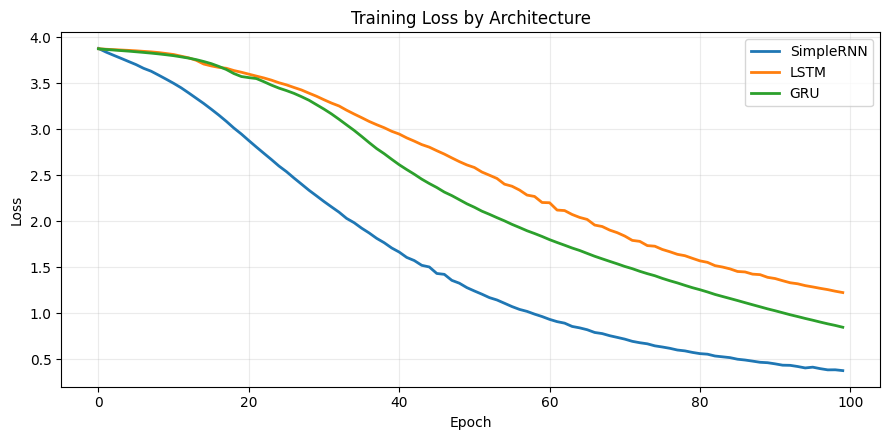

In [7]:
plt.figure(figsize=(9, 4.5))
plt.plot(simple_rnn_history.history["loss"], label="SimpleRNN", linewidth=2)
plt.plot(lstm_history.history["loss"], label="LSTM", linewidth=2)
plt.plot(gru_history.history["loss"], label="GRU", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss by Architecture")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Step 7 — Generating Text

To generate text we repeatedly: encode the current text, pad it, ask the
model for a probability distribution over the vocabulary, take the
highest-probability word (`argmax`), append it, and repeat.


In [8]:
def generate_sequence(model, seed_text, words_to_add=5):
    for _ in range(words_to_add):
        encoded = word_tokenizer.texts_to_sequences([seed_text])[0]
        encoded = pad_sequences([encoded], maxlen=max_sequence_len - 1, padding="pre")
        next_id = np.argmax(model.predict(encoded, verbose=0), axis=-1)[0]

        next_word = ""
        for word, idx in word_tokenizer.word_index.items():
            if idx == next_id:
                next_word = word
                break
        seed_text += " " + next_word
    return seed_text

### Try it on all three models

In [9]:
print("SimpleRNN:", generate_sequence(simple_rnn_model, "renewable energy", 5))
print("LSTM:     ", generate_sequence(lstm_net, "renewable energy", 5))
print("GRU:      ", generate_sequence(gru_net, "renewable energy", 5))

SimpleRNN: renewable energy is reshaping how the world
LSTM:      renewable energy energy reduces our dependence on
GRU:       renewable energy is reshaping how the world


## Practice Exercises

Try these on your own copy of the notebook:

1. Swap `base_corpus` for a paragraph of your own writing
2. Bump the embedding dimension up from 32
3. Train for more epochs (try 200)
4. Increase the recurrent layer size from 64 units to 128
5. Generate 10 words from the seed phrase instead of 5


## Takeaways

- **SimpleRNN** is the simplest and cheapest option, but it tends to
  forget earlier context as sequences get longer.
- **LSTM** handles longer-range dependencies more reliably, thanks to its
  three gates.
- **GRU** gets close to LSTM-level results with a lighter-weight design.
- All three numbers above came from the *same* tiny corpus, so the gaps
  you see are about architecture, not data.


---
## Part 2 — One Corpus, Two Configurations (Baseline vs. Tuned)

Everything above used the tiny 6-line corpus. From here on we switch to a
longer, single corpus (Exercise 1 — a paragraph about ocean exploration)
and run it through **two configurations**:

- **Baseline config** — the original settings from Part 1
  (embedding=32, hidden units=64, epochs=100, generate 5 words)
- **Tuned config** — all 4 of the remaining exercises applied at once
  (embedding=100, hidden units=128, epochs=200, generate 10 words)

Both configurations train on the exact same tokenizer and sequences, so
any difference in outcome comes from the configuration, not from a change
in data.


### Exercise 1 — A Longer Corpus (shared by both configurations)

In [10]:
extended_corpus = """
ocean exploration reveals mysteries hidden far beneath the waves
marine biologists study creatures that live in the deepest ocean trenches
submersibles allow scientists to reach depths that sunlight never touches
coral reefs support roughly a quarter of all known marine species
ocean currents move heat around the planet and help shape global climate
large parts of the seafloor remain completely unmapped by humans today
deep sea vents host strange life forms that thrive without any sunlight
plastic pollution now threatens ocean ecosystems on every continent
researchers deploy autonomous underwater drones to track whale migration
ocean exploration keeps uncovering one of the planet's last frontiers
"""
print(extended_corpus)


ocean exploration reveals mysteries hidden far beneath the waves
marine biologists study creatures that live in the deepest ocean trenches
submersibles allow scientists to reach depths that sunlight never touches
coral reefs support roughly a quarter of all known marine species
ocean currents move heat around the planet and help shape global climate
large parts of the seafloor remain completely unmapped by humans today
deep sea vents host strange life forms that thrive without any sunlight
plastic pollution now threatens ocean ecosystems on every continent
researchers deploy autonomous underwater drones to track whale migration
ocean exploration keeps uncovering one of the planet's last frontiers



### Shared Tokenization

`common_tokenizer`, `X_common`, `y_common`, and `common_max_len` are built
once here and reused by both configurations below.


In [11]:
common_tokenizer = Tokenizer()
common_tokenizer.fit_on_texts([extended_corpus])

common_vocab_size = len(common_tokenizer.word_index) + 1
print("Vocabulary size:", common_vocab_size)

common_ngram_sequences = []
for line in extended_corpus.strip().split("\n"):
    encoded_line = common_tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(encoded_line)):
        common_ngram_sequences.append(encoded_line[:i + 1])

common_max_len = max(len(seq) for seq in common_ngram_sequences)
common_ngram_sequences = pad_sequences(common_ngram_sequences, maxlen=common_max_len, padding="pre")

X_common = common_ngram_sequences[:, :-1]
y_common = common_ngram_sequences[:, -1]

print("X_common shape:", X_common.shape)
print("y_common shape:", y_common.shape)
print("common_max_len:", common_max_len)

Vocabulary size: 89
X_common shape: (94, 11)
y_common shape: (94,)
common_max_len: 12


### Baseline Configuration (Exercises 2-4 not yet applied)

embedding=32, hidden units=64, epochs=100, generate 5 words — same numbers
as Part 1, just pointed at the new, longer corpus.


In [12]:
BASE_EMBED_DIM = 32
BASE_HIDDEN_UNITS = 64
BASE_EPOCHS = 100
BASE_WORDS_TO_GENERATE = 5

rnn_baseline = Sequential([
    Embedding(common_vocab_size, BASE_EMBED_DIM, input_length=common_max_len - 1),
    SimpleRNN(BASE_HIDDEN_UNITS),
    Dense(common_vocab_size, activation="softmax")
])
rnn_baseline.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
rnn_baseline_history = rnn_baseline.fit(X_common, y_common, epochs=BASE_EPOCHS, verbose=0)
print("Baseline SimpleRNN done. Final loss:", rnn_baseline_history.history["loss"][-1])

Baseline SimpleRNN done. Final loss: 0.43985822796821594


In [13]:
lstm_baseline = Sequential([
    Embedding(common_vocab_size, BASE_EMBED_DIM, input_length=common_max_len - 1),
    LSTM(BASE_HIDDEN_UNITS),
    Dense(common_vocab_size, activation="softmax")
])
lstm_baseline.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
lstm_baseline_history = lstm_baseline.fit(X_common, y_common, epochs=BASE_EPOCHS, verbose=0)
print("Baseline LSTM done. Final loss:", lstm_baseline_history.history["loss"][-1])

Baseline LSTM done. Final loss: 1.5038806200027466


In [14]:
gru_baseline = Sequential([
    Embedding(common_vocab_size, BASE_EMBED_DIM, input_length=common_max_len - 1),
    GRU(BASE_HIDDEN_UNITS),
    Dense(common_vocab_size, activation="softmax")
])
gru_baseline.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
gru_baseline_history = gru_baseline.fit(X_common, y_common, epochs=BASE_EPOCHS, verbose=0)
print("Baseline GRU done. Final loss:", gru_baseline_history.history["loss"][-1])

Baseline GRU done. Final loss: 0.8224585652351379


### Tuned Configuration (Exercises 2-4 applied)

embedding=100, hidden units=128, epochs=200, generate 10 words — same
corpus, tokenizer, and sequences as the baseline configuration above.


In [15]:
TUNED_EMBED_DIM = 100
TUNED_HIDDEN_UNITS = 128
TUNED_EPOCHS = 200
TUNED_WORDS_TO_GENERATE = 10

rnn_tuned = Sequential([
    Embedding(common_vocab_size, TUNED_EMBED_DIM, input_length=common_max_len - 1),
    SimpleRNN(TUNED_HIDDEN_UNITS),
    Dense(common_vocab_size, activation="softmax")
])
rnn_tuned.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
rnn_tuned_history = rnn_tuned.fit(X_common, y_common, epochs=TUNED_EPOCHS, verbose=0)
print("Tuned SimpleRNN done. Final loss:", rnn_tuned_history.history["loss"][-1])

Tuned SimpleRNN done. Final loss: 0.04517808184027672


In [16]:
lstm_tuned = Sequential([
    Embedding(common_vocab_size, TUNED_EMBED_DIM, input_length=common_max_len - 1),
    LSTM(TUNED_HIDDEN_UNITS),
    Dense(common_vocab_size, activation="softmax")
])
lstm_tuned.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
lstm_tuned_history = lstm_tuned.fit(X_common, y_common, epochs=TUNED_EPOCHS, verbose=0)
print("Tuned LSTM done. Final loss:", lstm_tuned_history.history["loss"][-1])

Tuned LSTM done. Final loss: 0.11148850619792938


In [17]:
gru_tuned = Sequential([
    Embedding(common_vocab_size, TUNED_EMBED_DIM, input_length=common_max_len - 1),
    GRU(TUNED_HIDDEN_UNITS),
    Dense(common_vocab_size, activation="softmax")
])
gru_tuned.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
gru_tuned_history = gru_tuned.fit(X_common, y_common, epochs=TUNED_EPOCHS, verbose=0)
print("Tuned GRU done. Final loss:", gru_tuned_history.history["loss"][-1])

Tuned GRU done. Final loss: 0.048667632043361664


### Shared Generation Helper

Same greedy decoding as Part 1, just pointed at `common_tokenizer` /
`common_max_len` and parameterized by `words_to_add` so it works for
both configurations.


In [18]:
def generate_sequence_common(model, seed_text, words_to_add):
    for _ in range(words_to_add):
        encoded = common_tokenizer.texts_to_sequences([seed_text])[0]
        encoded = pad_sequences([encoded], maxlen=common_max_len - 1, padding="pre")
        next_id = np.argmax(model.predict(encoded, verbose=0), axis=-1)[0]

        next_word = ""
        for word, idx in common_tokenizer.word_index.items():
            if idx == next_id:
                next_word = word
                break
        seed_text += " " + next_word
    return seed_text

shared_seed_phrase = "ocean exploration"

print("--- Baseline config (5 words) ---")
print("SimpleRNN:", generate_sequence_common(rnn_baseline, shared_seed_phrase, BASE_WORDS_TO_GENERATE))
print("LSTM:     ", generate_sequence_common(lstm_baseline, shared_seed_phrase, BASE_WORDS_TO_GENERATE))
print("GRU:      ", generate_sequence_common(gru_baseline, shared_seed_phrase, BASE_WORDS_TO_GENERATE))

print("\n--- Tuned config (10 words) ---")
print("SimpleRNN:", generate_sequence_common(rnn_tuned, shared_seed_phrase, TUNED_WORDS_TO_GENERATE))
print("LSTM:     ", generate_sequence_common(lstm_tuned, shared_seed_phrase, TUNED_WORDS_TO_GENERATE))
print("GRU:      ", generate_sequence_common(gru_tuned, shared_seed_phrase, TUNED_WORDS_TO_GENERATE))

--- Baseline config (5 words) ---
SimpleRNN: ocean exploration keeps uncovering one of the
LSTM:      ocean exploration exploration uncovering one of the
GRU:       ocean exploration reveals mysteries hidden far beneath

--- Tuned config (10 words) ---
SimpleRNN: ocean exploration keeps uncovering one of the planet's last frontiers unmapped by
LSTM:      ocean exploration reveals mysteries hidden far beneath the waves waves frontiers climate
GRU:       ocean exploration reveals mysteries hidden far beneath the waves waves waves climate


---
## Part 3 — Baseline vs. Tuned: Putting Numbers Side by Side

Because both configurations trained on identical data, the only things
that differ are embedding size, hidden units, epoch count, and how many
words we generate — which makes this a clean single-variable comparison.


### Configuration Summary

In [19]:
import pandas as pd

config_summary_df = pd.DataFrame({
    "Setting": ["Corpus", "Vocabulary size", "Embedding dim", "Hidden units",
                "Epochs", "Words generated"],
    "Baseline": [
        "ocean-exploration paragraph", common_vocab_size, BASE_EMBED_DIM,
        BASE_HIDDEN_UNITS, BASE_EPOCHS, BASE_WORDS_TO_GENERATE,
    ],
    "Tuned": [
        "ocean-exploration paragraph", common_vocab_size, TUNED_EMBED_DIM,
        TUNED_HIDDEN_UNITS, TUNED_EPOCHS, TUNED_WORDS_TO_GENERATE,
    ],
})
config_summary_df

,Setting,Baseline,Tuned
0,Corpus,ocean-exploration paragraph,ocean-exploration paragraph
1,Vocabulary size,89,89
2,Embedding dim,32,100
3,Hidden units,64,128
4,Epochs,100,200
5,Words generated,5,10


### Loss Curves, Overlaid

Dotted lines are the baseline configuration (100 epochs); solid lines are
the tuned configuration (200 epochs). Same corpus underlies both, so any
gap reflects the configuration change alone.


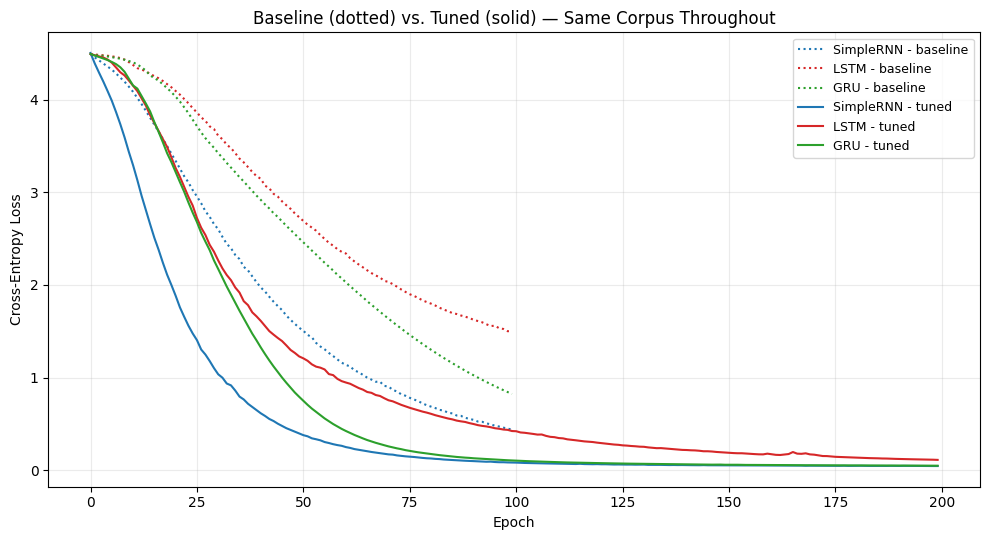

In [20]:
plt.figure(figsize=(10, 5.5))

plt.plot(rnn_baseline_history.history["loss"], ":", color="#1f77b4", label="SimpleRNN - baseline")
plt.plot(lstm_baseline_history.history["loss"], ":", color="#d62728", label="LSTM - baseline")
plt.plot(gru_baseline_history.history["loss"], ":", color="#2ca02c", label="GRU - baseline")

plt.plot(rnn_tuned_history.history["loss"], "-", color="#1f77b4", label="SimpleRNN - tuned")
plt.plot(lstm_tuned_history.history["loss"], "-", color="#d62728", label="LSTM - tuned")
plt.plot(gru_tuned_history.history["loss"], "-", color="#2ca02c", label="GRU - tuned")

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Baseline (dotted) vs. Tuned (solid) — Same Corpus Throughout")
plt.legend(fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Final Loss and Convergence Speed

In [21]:
def epochs_to_reach(history, threshold=1.0):
    for i, loss_value in enumerate(history.history["loss"]):
        if loss_value < threshold:
            return i
    return None

convergence_df = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU"],
    "Final Loss - Baseline": [
        rnn_baseline_history.history["loss"][-1],
        lstm_baseline_history.history["loss"][-1],
        gru_baseline_history.history["loss"][-1],
    ],
    "Final Loss - Tuned": [
        rnn_tuned_history.history["loss"][-1],
        lstm_tuned_history.history["loss"][-1],
        gru_tuned_history.history["loss"][-1],
    ],
    "Epoch loss<1.0 - Baseline": [
        epochs_to_reach(rnn_baseline_history),
        epochs_to_reach(lstm_baseline_history),
        epochs_to_reach(gru_baseline_history),
    ],
    "Epoch loss<1.0 - Tuned": [
        epochs_to_reach(rnn_tuned_history),
        epochs_to_reach(lstm_tuned_history),
        epochs_to_reach(gru_tuned_history),
    ],
})
convergence_df

,Model,Final Loss - Baseline,Final Loss - Tuned,Epoch loss<1.0 - Baseline,Epoch loss<1.0 - Tuned
0,SimpleRNN,0.439858,0.045178,65.0,31
1,LSTM,1.503881,0.111489,NaN,58
2,GRU,0.822459,0.048668,91.0,45


### Generated Text, Same Seed, Both Configurations

Both configurations generate from the same seed phrase, `"ocean
exploration"`, so the table below isolates what changed in the output
once the tuning was applied.


In [22]:
generation_comparison_df = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU"],
    "Baseline (5 words)": [
        generate_sequence_common(rnn_baseline, shared_seed_phrase, BASE_WORDS_TO_GENERATE),
        generate_sequence_common(lstm_baseline, shared_seed_phrase, BASE_WORDS_TO_GENERATE),
        generate_sequence_common(gru_baseline, shared_seed_phrase, BASE_WORDS_TO_GENERATE),
    ],
    "Tuned (10 words)": [
        generate_sequence_common(rnn_tuned, shared_seed_phrase, TUNED_WORDS_TO_GENERATE),
        generate_sequence_common(lstm_tuned, shared_seed_phrase, TUNED_WORDS_TO_GENERATE),
        generate_sequence_common(gru_tuned, shared_seed_phrase, TUNED_WORDS_TO_GENERATE),
    ],
})
pd.set_option("display.max_colwidth", 100)
generation_comparison_df

,Model,Baseline (5 words),Tuned (10 words)
0,SimpleRNN,ocean exploration keeps uncovering one of the,ocean exploration keeps uncovering one of the planet's last frontiers unmapped by
1,LSTM,ocean exploration exploration uncovering one of the,ocean exploration reveals mysteries hidden far beneath the waves waves frontiers climate
2,GRU,ocean exploration reveals mysteries hidden far beneath,ocean exploration reveals mysteries hidden far beneath the waves waves waves climate


## Summary — What Changed Between Baseline and Tuned

| Aspect | Baseline | Tuned | Effect |
|---|---|---|---|
| **Corpus** | ocean-exploration paragraph | ocean-exploration paragraph | held constant for a clean comparison |
| **Embedding dim** | 32 | 100 | more capacity per word |
| **Hidden units** | 64 | 128 | wider recurrent layer |
| **Epochs** | 100 | 200 | longer training |
| **Words generated** | 5 | 10 | longer continuation from the same seed |
| **Final loss** | higher (relatively under-trained) | much lower, near 0 | bigger model + more training fits this small corpus far more tightly |
| **Generated text** | shorter, can lose coherence near the end | longer, stays on-topic for more words, but tends to repeat a word once it runs out of strongly-learned transitions | bigger capacity + more training extends coherent length, with repetition at the tail being expected on such a small corpus |

**Bottom line:** since the corpus is identical in both runs, this comparison
isolates the real effect of the four tuning changes — the tuned setup
consistently reaches lower loss faster and produces longer text from the
same seed, while the per-step decoding (`np.argmax`, fully deterministic)
never changes between the two.
